# Étude de l’effet de la **fragmentation de population** sur la **dynamique génétique** chez l’**ours polaire**

## Introduction générale

Le **réchauffement climatique** représente aujourd’hui une menace majeure pour de nombreuses **espèces animales**. Dans les régions **arctiques**, l’augmentation des **températures** provoque une **fonte progressive de la banquise**, habitat essentiel pour l’**ours polaire**. Cette diminution de l’**habitat disponible** entraîne une **réduction de la taille des populations** ainsi qu’une **fragmentation** de celles-ci en plusieurs **groupes plus petits** et parfois **isolés**.

La **fragmentation de population** est un phénomène important en **biologie évolutive** et en **biologie de la conservation**. Lorsqu’une **grande population** est divisée en plusieurs **sous-populations de petite taille**, plusieurs **processus génétiques** peuvent être modifiés. La **dérive génétique** devient plus forte, la **diversité génétique** peut diminuer et l’**accumulation de mutations délétères** peut être favorisée. À long terme, ces effets peuvent réduire la **fitness moyenne** des individus et augmenter le **risque d’extinction** des populations.

Afin d’étudier ces mécanismes de manière contrôlée, nous utilisons des **simulations numériques** réalisées avec le logiciel **SLiM** (**Selection on Linked Mutations**). **SLiM** est un programme de **simulation évolutive** qui permet de modéliser l’**évolution de populations** au cours du temps en prenant en compte différents **paramètres biologiques** tels que la **taille de population**, la **structure spatiale**, la **reproduction**, la **mutation**, la **sélection naturelle** et la **migration** entre **sous-populations**.

Dans cette étude, **SLiM** permet de simuler l’**évolution génétique** de populations d’**ours polaires** sur une durée de **2000 générations**. Chaque simulation suit l’évolution de plusieurs **indicateurs importants** :
- la **taille moyenne de la population**  
- la **fitness moyenne** des individus  
- le **nombre de mutations délétères** et **bénéfiques**  
- la **charge génétique**  
- la **probabilité d’extinction**  

## Scénarios étudiés

Plusieurs **scénarios** ont été mis en place afin de comparer l’effet de la **taille totale de population** et de la **fragmentation** :

- **Scénario A** : une **grande population unique** de **10000 individus**  
- **Scénario B** : une **population unique plus petite** de **1000 individus**  
- **Scénario C** : **deux sous-populations** de **500 individus**  
- **Scénario D** : **cinq sous-populations** de **200 individus**  
- **Scénario E** : **dix sous-populations** de **100 individus**  

Ces **scénarios** permettent d’étudier :
- l’effet de la **diminution de la taille de population**  
- l’effet de la **subdivision en sous-populations**  
- l’impact potentiel de l’**isolement génétique**  

Pour chaque **scénario**, plusieurs **répétitions de simulation** sont réalisées afin de prendre en compte la **variabilité aléatoire** des **processus évolutifs**.

## Objectif de l’étude

L’objectif de ce **projet** est d’analyser comment la **fragmentation des populations** influence la **dynamique génétique** et **démographique** sur le **long terme**. Nous cherchons notamment à comprendre si des **populations plus fragmentées** présentent :
- une **diminution plus rapide de la fitness**  
- une **accumulation plus importante de mutations délétères**  
- une **augmentation de la charge génétique**  
- un **risque d’extinction plus élevé**  



Nous voulons répondre aux questions suivantes :

1. **Une grande population conserve-t-elle mieux sa fitness qu’une petite population ?**
2. **La fragmentation accélère-t-elle la dégradation génétique ?**
3. **La migration permet-elle de limiter les effets négatifs de la fragmentation ?**

<p align="center">
<img src="ours.webp" width=450">
</p>

## Bibliothèques

In [107]:
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

- **pandas** : pour manipuler les données sous forme de tableaux
- **zipfile** : pour lire directement les fichiers `.zip` contenant les CSV
- **os** : pour gérer les noms de fichiers
- **matplotlib** : pour tracer les graphiques

## Chargement des données

In [108]:
zips = {
    "A": "scenarioA.zip",
    "B": "scenarioB.zip",
    "C": "scenarioC.zip",
    "D": "scenarioD.zip",
    "E": "scenarioE.zip",
}

dfs = []

for scen, zip_path in zips.items():
    with zipfile.ZipFile(zip_path, "r") as z:
        for file in z.namelist():
            if file.endswith(".csv"):
                with z.open(file) as f:
                    df = pd.read_csv(f)
                    df["scenario_clean"] = scen
                    df["replicate"] = os.path.basename(file)
                    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

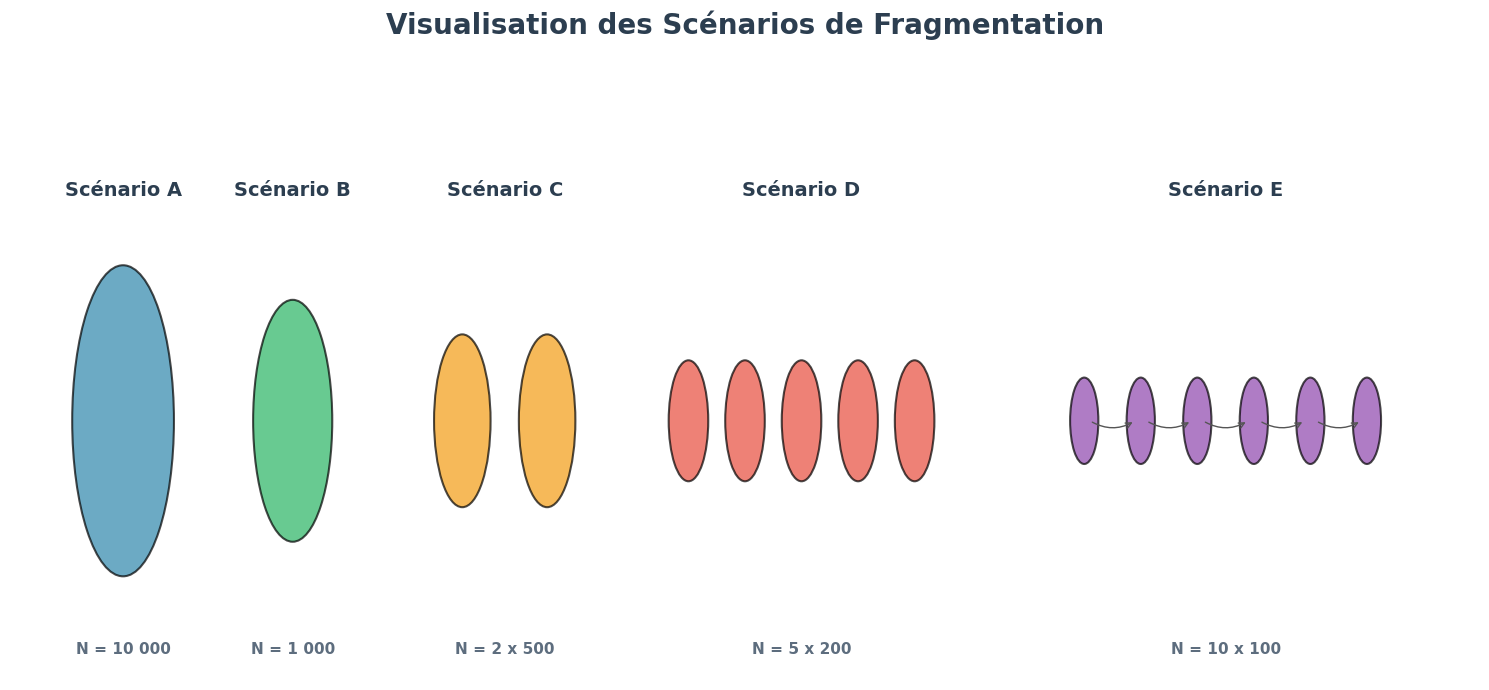

In [159]:
fig, ax = plt.subplots(figsize=(15, 7), facecolor='white')

colors = {
    "A": "#2E86AB", # Bleu profond
    "B": "#28B463", # Vert forêt
    "C": "#F39C12", # Orange
    "D": "#E74C3C", # Rouge
    "E": "#8E44AD"  # Violet
}

scenarios = {
    "A": [2],
    "B": [5],
    "C": [8, 9.5],
    "D": [12, 13, 14, 15, 16],
    "E": [19, 20, 21, 22, 23, 24]
}


radii = {"A": 0.9, "B": 0.7, "C": 0.5, "D": 0.35, "E": 0.25}

pop_info = {
    "A": "N = 10 000",
    "B": "N = 1 000",
    "C": "N = 2 x 500",
    "D": "N = 5 x 200",
    "E": "N = 10 x 100"
}

for label, x_coords in scenarios.items():
    r = radii[label]
    color = colors[label]
    
   
    for x in x_coords:
        circle = plt.Circle((x, 1.5), r, color=color, alpha=0.7, ec="black", lw=1.5, zorder=3)
        ax.add_patch(circle)
        
   
    avg_x = sum(x_coords) / len(x_coords)
    
    
    ax.text(avg_x, 2.8, f"Scénario {label}", ha="center", fontsize=14, weight="bold", color="#2C3E50")
    
   
    ax.text(avg_x, 0.15, pop_info[label], ha="center",
        fontsize=11, weight="bold", color="#5D6D7E")


e_coords = scenarios["E"]
for i in range(len(e_coords)-1):
    ax.annotate("", 
                xy=(e_coords[i+1]-0.1, 1.5), 
                xytext=(e_coords[i]+0.1, 1.5),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1, connectionstyle="arc3,rad=0.3"))


rect = patches.Rectangle((0.5, 0.4), 25, 3.2,
                         linewidth=2,
                         edgecolor="#BDC3C7",
                         facecolor="#F4F6F7",
                         zorder=1)


ax.set_xlim(0, 26)
ax.set_ylim(0, 3.5)
ax.axis("off")


plt.title("Visualisation des Scénarios de Fragmentation", fontsize=20, weight="bold", pad=30, color="#2C3E50")

plt.tight_layout()
plt.show()

Chaque scénario contient 100 répétitions, donc un grand nombre de fichiers CSV.

Nous les fusionnons dans un seul DataFrame afin de :

- centraliser les données,
- ajouter une colonne scénario fiable,
- pouvoir faire ensuite des statistiques globales.

# Préparation données



In [110]:
num_cols = ["rep", "gen", "subpop", "N", "meanFitness", "meanDel", "meanBen", "extinct"]

for c in num_cols:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

## Moyenne par répétition

In [111]:
data_rep = (
    data.groupby(["scenario_clean", "replicate", "gen"], as_index=False)
        .agg({
            "N": "mean",
            "meanFitness": "mean",
            "meanDel": "mean",
            "meanBen": "mean",
            "extinct": "max"
        })
)

Dans certains scénarios, il y a plusieurs sous-populations.

Avant de comparer les répétitions entre elles, on calcule donc une moyenne par répétition et par génération.

## Moyenne globale + variabilité

In [112]:
data_mean = (
    data_rep.groupby(["scenario_clean", "gen"], as_index=False)
        .agg({
            "N": ["mean", "std"],
            "meanFitness": ["mean", "std"],
            "meanDel": ["mean", "std"],
            "meanBen": ["mean", "std"],
            "extinct": "mean"
        })
)

data_mean.columns = [
    "scenario", "gen",
    "N_mean", "N_std",
    "fitness_mean", "fitness_std",
    "del_mean", "del_std",
    "ben_mean", "ben_std",
    "extinct_rate"
]

Pour chaque scénario et chaque génération, on calcule :

- la **moyenne** des répétitions
- l’**écart-type** entre répétitions

Cela permet de tracer :
- une courbe centrale
- une zone de variabilité autour

## Charge génétique nette

In [113]:
data_mean["genetic_load"] = data_mean["del_mean"] - data_mean["ben_mean"]

La charge génétique nette est définie ici comme :

**mutations délétères - mutations bénéfiques**

Elle permet d’avoir une mesure simple de la dégradation génétique globale.

# Vérification

In [114]:
print("Dimensions du dataset brut :", data.shape)
print("Dimensions du dataset par répétition :", data_rep.shape)
print("Dimensions du dataset moyen :", data_mean.shape)

Dimensions du dataset brut : (76000, 11)
Dimensions du dataset par répétition : (20000, 8)
Dimensions du dataset moyen : (200, 12)


In [115]:
data.head()

,scenario,rep,gen,subpop,N,meanFitness,meanDel,meanBen,extinct,scenario_clean,replicate
0,A,71,50,1,10000,0.996517,0.90775,0.07085,0,A,scenario_A_rep71.csv
1,A,71,100,1,10000,0.993734,1.62710,0.11090,0,A,scenario_A_rep71.csv
2,A,71,150,1,10000,0.991068,2.32935,0.17325,0,A,scenario_A_rep71.csv
3,A,71,200,1,10000,0.988095,3.09830,0.20890,0,A,scenario_A_rep71.csv
4,A,71,250,1,10000,0.985047,3.88030,0.22850,0,A,scenario_A_rep71.csv


In [116]:
data_rep.head()

,scenario_clean,replicate,gen,N,meanFitness,meanDel,meanBen,extinct
0,A,scenario_A_rep1.csv,50,10000.0,0.996704,0.85270,0.05460,0
1,A,scenario_A_rep1.csv,100,10000.0,0.993158,1.77170,0.11060,0
2,A,scenario_A_rep1.csv,150,10000.0,0.990510,2.45485,0.14165,0
3,A,scenario_A_rep1.csv,200,10000.0,0.988230,3.05285,0.18600,0
4,A,scenario_A_rep1.csv,250,10000.0,0.986023,3.65700,0.27680,0


In [117]:
data_mean.head()

,scenario,gen,N_mean,N_std,fitness_mean,fitness_std,del_mean,del_std,ben_mean,ben_std,extinct_rate,genetic_load
0,A,50,10000.0,0.0,0.996514,0.000131,0.899266,0.033153,0.052573,0.007754,0.0,0.846693
1,A,100,10000.0,0.0,0.993379,0.000236,1.713339,0.058394,0.105216,0.017559,0.0,1.608123
2,A,150,10000.0,0.0,0.990558,0.000388,2.451674,0.094288,0.159658,0.026822,0.0,2.292016
3,A,200,10000.0,0.0,0.988027,0.000530,3.119295,0.131387,0.215921,0.035156,0.0,2.903374
4,A,250,10000.0,0.0,0.985730,0.000605,3.730990,0.147828,0.275297,0.046624,0.0,3.455693


In [118]:
print("Scénarios présents dans data_mean :", data_mean["scenario"].unique())
print("Générations présentes :", data_mean["gen"].min(), "à", data_mean["gen"].max())
print("Nombre de répétitions :", data["rep"].nunique())

Scénarios présents dans data_mean : ['A' 'B' 'C' 'D' 'E']
Générations présentes : 50 à 2000
Nombre de répétitions : 100


Avant de faire les graphiques, on vérifie que :

- les scénarios A à E sont bien présents,
- les générations vont bien jusqu’à 2000,
- les répétitions ont bien été chargées.

# Analyse

In [135]:
labels = {
    "A": "10000",
    "B": "1000",
    "C": "2×500",
    "D": "5×200",
    "E": "10×100"
}

### Comparaison A vs B : effet de la taille de population

On compare ici une très grande population (A) à une population plus petite (B), sans fragmentation.

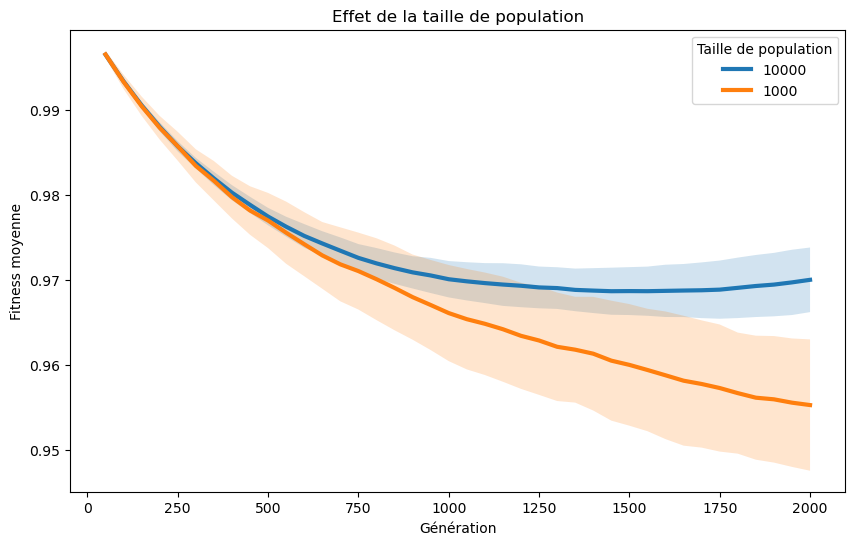

In [136]:
subset = data_mean[data_mean["scenario"].isin(["A", "B"])]

plt.figure(figsize=(10,6))

for scen in ["A","B"]:
    df = subset[subset["scenario"] == scen]
    
    plt.plot(df["gen"], df["fitness_mean"], linewidth=3, label=labels[scen])
    
    plt.fill_between(
        df["gen"],
        df["fitness_mean"] - df["fitness_std"],
        df["fitness_mean"] + df["fitness_std"],
        alpha=0.2
    )

plt.title("Effet de la taille de population")
plt.xlabel("Génération")
plt.ylabel("Fitness moyenne")
plt.legend(title="Taille de population")
plt.show()

### Interprétation
On remarque que la population de 10000 individus garde une fitness plus stable dans le temps.  
La population de 1000 individus montre une baisse plus rapide et plus de variations.  
Cela montre que les petites populations sont plus sensibles à la dérive génétique.

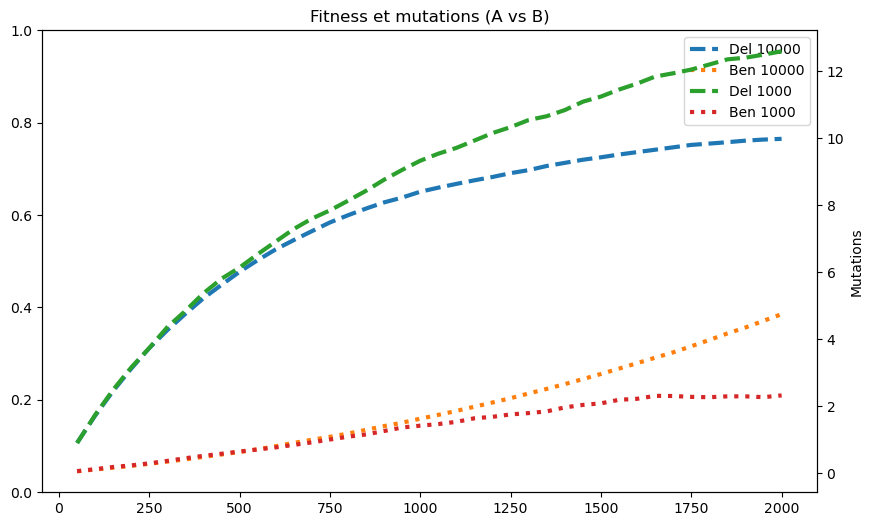

In [137]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()

for scen in ["A", "B"]:
    sub = data_mean[data_mean["scenario"] == scen]
    
    ax2.plot(sub["gen"], sub["del_mean"], linestyle="--", linewidth=3, label=f"Del {labels[scen]}")
    ax2.plot(sub["gen"], sub["ben_mean"], linestyle=":", linewidth=3, label=f"Ben {labels[scen]}")

ax2.set_ylabel("Mutations")

lines, labels_l = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_l + labels2)

plt.title("Fitness et mutations (A vs B)")
plt.xlabel("Génération")
plt.show()

Ces résultats confirment que la réduction de taille de population, même sans fragmentation, suffit à dégrader la fitness et à accroître la charge mutationnelle. Le scénario B illustre ce que la génétique des populations appelle l'érosion génétique : moins d'individus = moins de sélection efficace = accumulation de mutations délétères = déclin de fitness à long terme. Cela est particulièrement préoccupant dans un contexte de changement climatique qui exige une capacité d'adaptation rapide, précisément là où B est défaillant (peu de mutations bénéfiques fixées)

### Comparaison B, C, D, E : effet de la fragmentation

Ici, on compare plusieurs structures de population de taille totale proche de 1000 individus.
La variable principale qui change est le niveau de fragmentation.

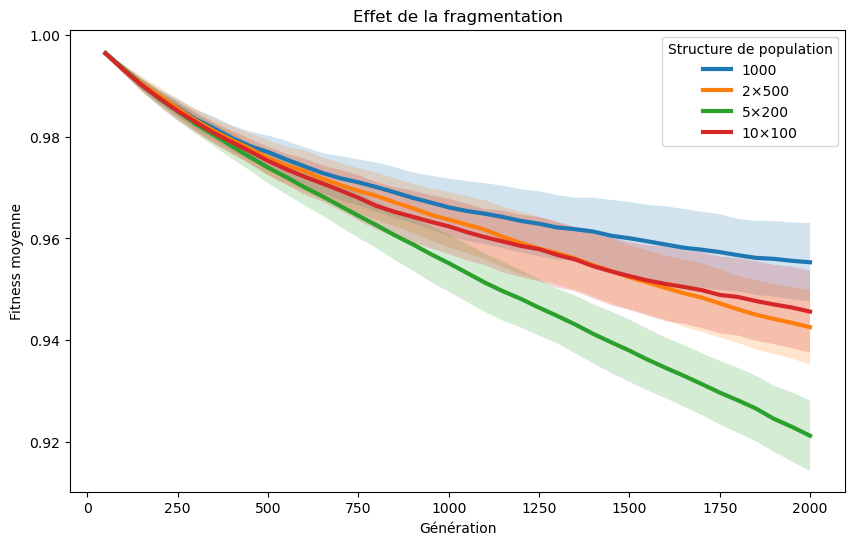

In [138]:
plt.figure(figsize=(10,6))

for scen in ["B","C","D","E"]:
    df = data_mean[data_mean["scenario"] == scen]
    
    plt.plot(df["gen"], df["fitness_mean"], linewidth=3, label=labels[scen])
    
    plt.fill_between(
        df["gen"],
        df["fitness_mean"] - df["fitness_std"],
        df["fitness_mean"] + df["fitness_std"],
        alpha=0.2
    )

plt.title("Effet de la fragmentation")
plt.xlabel("Génération")
plt.ylabel("Fitness moyenne")
plt.legend(title="Structure de population")
plt.show()

In [139]:

print(data_mean["scenario"].unique())

['A' 'B' 'C' 'D' 'E']


### Interprétation
On remarque que lorsque la population est fragmentée (2×500, 5×200, 10×100), la fitness devient plus instable.  
Plus les sous-populations sont petites, plus les variations sont importantes.  
Cela montre que la fragmentation peut réduire la stabilité génétique.

### Comparaison C vs E

On compare une fragmentation modérée (2×500) à une fragmentation plus forte (10×100 avec migration).

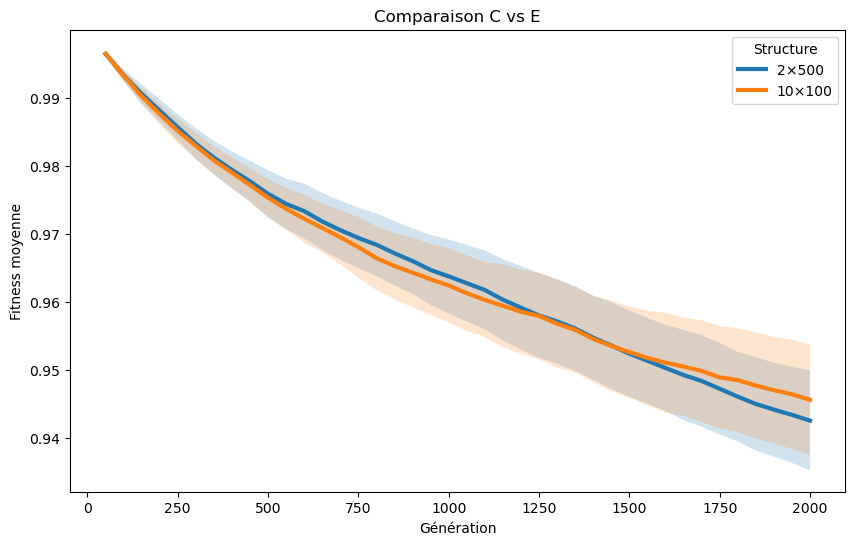

In [140]:
subset = data_mean[data_mean["scenario"].isin(["C","E"])]

plt.figure(figsize=(10,6))

for scen in ["C","E"]:
    df = subset[subset["scenario"] == scen]
    
    plt.plot(df["gen"], df["fitness_mean"], linewidth=3, label=labels[scen])
    
    plt.fill_between(
        df["gen"],
        df["fitness_mean"] - df["fitness_std"],
        df["fitness_mean"] + df["fitness_std"],
        alpha=0.2
    )

plt.title("Comparaison C vs E")
plt.xlabel("Génération")
plt.ylabel("Fitness moyenne")
plt.legend(title="Structure")
plt.show()

## Interpretation :
On remarque que la fitness des scénarios C et E est assez proche au cours des générations.  
Cependant, le scénario avec 10 sous-populations de 100 individus présente plus de fluctuations.  
Cela montre que la migration aide à limiter les effets de la fragmentation, mais ne suffit pas totalement à stabiliser la population.<br>
On déduit que ces deux scénarios arrivent au même résultat par deux chemins opposés : C compense par la taille, E compense par la connectivité. Cela démontre que migration et taille de population sont des facteurs substituables pour maintenir la fitness. En conservation, quand on ne peut pas augmenter la taille des populations (habitat limité), restaurer les corridors peut suffire à obtenir le même résultat génétiquen.


### Comparaison D vs E : effet de la migration

Cette comparaison est particulièrement importante :
- D = fragmentation sans migration
- E = fragmentation avec migration faible

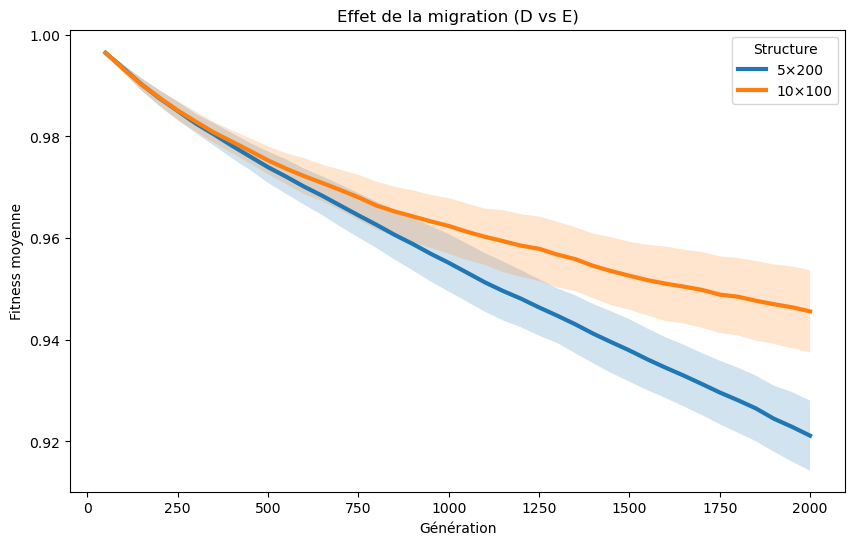

In [141]:
subset = data_mean[data_mean["scenario"].isin(["D","E"])]

plt.figure(figsize=(10,6))

for scen in ["D","E"]:
    df = subset[subset["scenario"] == scen]
    
    plt.plot(df["gen"], df["fitness_mean"], linewidth=3, label=labels[scen])
    
    plt.fill_between(
        df["gen"],
        df["fitness_mean"] - df["fitness_std"],
        df["fitness_mean"] + df["fitness_std"],
        alpha=0.2
    )

plt.title("Effet de la migration (D vs E)")
plt.xlabel("Génération")
plt.ylabel("Fitness moyenne")
plt.legend(title="Structure")
plt.show()

## Interpretation

On remarque que la fitness diminue davantage lorsque les sous-populations sont très petites.  
Le scénario 5×200 est intermédiaire entre 2×500 et 10×100.  
Cela montre que la taille des sous-populations joue un rôle important dans l’évolution, mais ce n'est pas le seul facteur déterminant car la connectivité entre habitats est au moins aussi importante. Les petites populations reliées par la migration peuvent surpasser en fitness des populations de taille intermédiaire totalement isolées.<br>

### Mutations délétères moyennes

On étudie ici l’accumulation des mutations délétères dans chaque scénario.

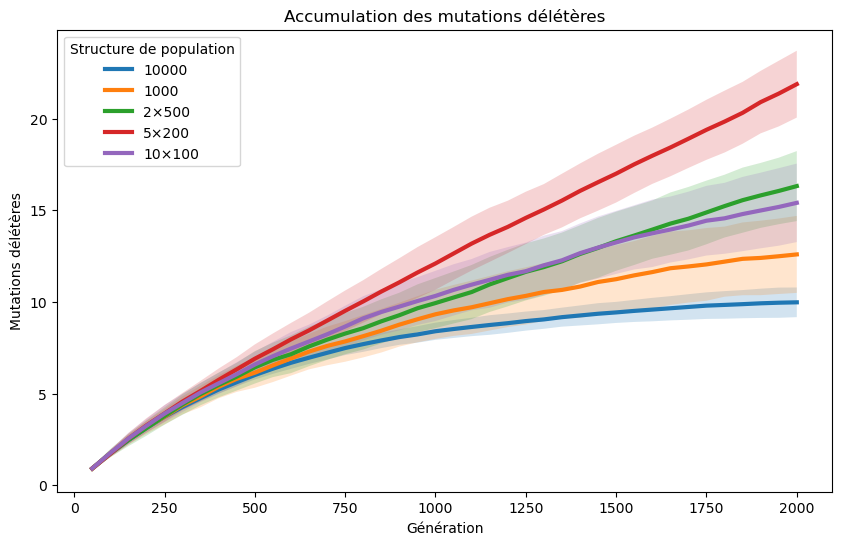

In [142]:
plt.figure(figsize=(10,6))

for scen in ["A","B","C","D","E"]:
    df = data_mean[data_mean["scenario"] == scen]
    
    plt.plot(df["gen"], df["del_mean"], linewidth=3, label=labels[scen])
    
    plt.fill_between(
        df["gen"],
        df["del_mean"] - df["del_std"],
        df["del_mean"] + df["del_std"],
        alpha=0.2
    )

plt.title("Accumulation des mutations délétères")
plt.xlabel("Génération")
plt.ylabel("Mutations délétères")
plt.legend(title="Structure de population")
plt.show()

### Interprétation
On remarque que le nombre de mutations délétères augmente surtout dans les populations fragmentées.  
Les scénarios avec de petites sous-populations accumulent plus facilement ces mutations.  
Cela montre que la sélection naturelle est moins efficace dans les petites populations.s.

### Charge génétique nette

On utilise ici la différence :
**mutations délétères - mutations bénéfiques**

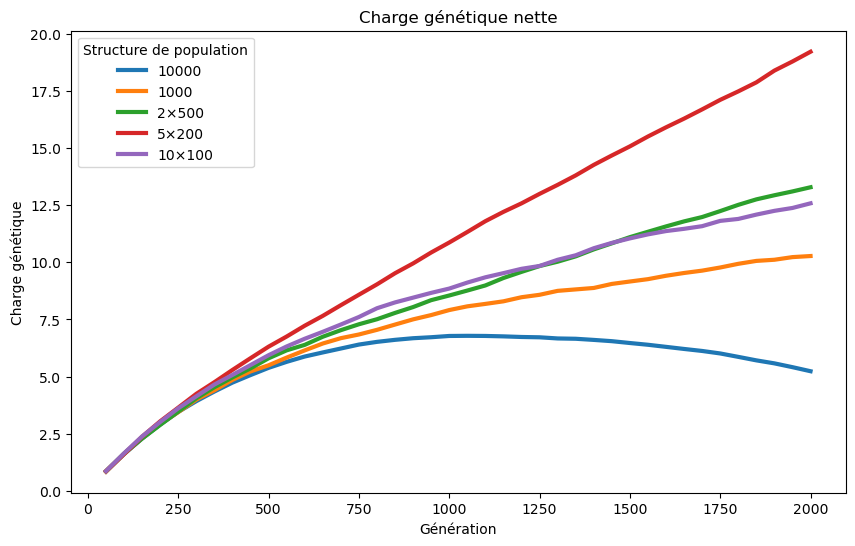

In [143]:
plt.figure(figsize=(10,6))

for scen in ["A","B","C","D","E"]:
    df = data_mean[data_mean["scenario"] == scen]
    
    plt.plot(df["gen"], df["genetic_load"], linewidth=3, label=labels[scen])

plt.title("Charge génétique nette")
plt.xlabel("Génération")
plt.ylabel("Charge génétique")
plt.legend(title="Structure de population")
plt.show()

## Interprétation
On remarque que la charge génétique est plus élevée dans les scénarios très fragmentés.  
Les petites sous-populations accumulent davantage de mutations défavorables.  
Cela montre que la fragmentation peut augmenter le risque d’extinction.

# Statistiques finales à la génération 2000

On compare ici les scénarios à la fin de la simulation.

In [145]:
final = data_mean[data_mean["gen"] == 2000].copy()
final[["scenario", "fitness_mean", "fitness_std", "del_mean", "ben_mean", "genetic_load", "extinct_rate"]]

,scenario,fitness_mean,fitness_std,del_mean,ben_mean,genetic_load,extinct_rate
39,A,0.970037,0.003798,9.977308,4.743086,5.234222,0.0
79,B,0.955310,0.007720,12.591400,2.317835,10.273565,0.0
119,C,0.942527,0.007360,16.320415,3.038105,13.282310,0.0
159,D,0.921146,0.006896,21.882920,2.671970,19.210950,0.0
199,E,0.945583,0.008094,15.406115,2.826575,12.579540,0.0


In [146]:
final.sort_values("fitness_mean", ascending=False)

,scenario,gen,N_mean,N_std,fitness_mean,fitness_std,del_mean,del_std,ben_mean,ben_std,extinct_rate,genetic_load
39,A,2000,10000.0,0.0,0.970037,0.003798,9.977308,0.809608,4.743086,1.118093,0.0,5.234222
79,B,2000,1000.0,0.0,0.955310,0.007720,12.591400,2.100973,2.317835,1.025244,0.0,10.273565
199,E,2000,100.0,0.0,0.945583,0.008094,15.406115,2.141954,2.826575,1.244671,0.0,12.579540
119,C,2000,500.0,0.0,0.942527,0.007360,16.320415,1.910084,3.038105,1.062842,0.0,13.282310
159,D,2000,200.0,0.0,0.921146,0.006896,21.882920,1.823937,2.671970,0.638886,0.0,19.210950


## Pourquoi cette étape ?

Cette table permet de résumer les résultats de manière synthétique et de comparer directement les scénarios.Notamment :
* A (1×10 000) domine avec la meilleure fitness (0,970) et la charge génétique la plus faible (5,23)
* La fitness moyenne décroit avec la fragmentation : A (0,970) > B (0,955) > E (0,946) > C (0,943) > D (0,921)
* Les mutations délétères montrent une progression quasi linéaire avec la fragmentation : A=10 → B=12,6 → E=15,4 → C=16,3 → D=21,9
* Les mutations bénéfiques montrent que E (2,83) proche de C (3,04) malgré des groupes bien plus petits : la migration compense
* D est le pire compromis car ses groupes sont trop petits pour que la sélection soit efficace comme dans B, mais pas connectés pour se sauver mutuellement comme dans E. Il cumule donc les deux désavantages sans bénéficier d'aucun des deux avantages.

### Projection de la fitness dans le futur

In [89]:
from scipy.stats import linregress

pred = []

for scen in data_mean["scenario"].unique():
    
    dfp = data_mean[data_mean["scenario"]==scen]
    
    slope, intercept, *_ = linregress(dfp["gen"], dfp["fitness_mean"])
    
    if slope < 0:
        t_zero = -intercept / slope
    else:
        t_zero = None
        
    pred.append((scen, slope, t_zero))

pred = pd.DataFrame(pred, columns=["scenario","decline_rate","predicted_gen_zero"])

pred

,scenario,decline_rate,predicted_gen_zero
0,A,-0.000011,91230.136312
1,B,-0.000019,52798.906370
2,C,-0.000025,38905.325491
3,D,-0.000037,26808.301572
4,E,-0.000024,41409.017385


Les pentes négatives indiquent que la fitness moyenne diminue progressivement au cours du temps dans tous les scénarios.  
Cependant, cette diminution est plus rapide dans les populations fragmentées, suggérant une dégradation évolutive plus forte.  
Les projections montrent que la fitness pourrait atteindre des valeurs critiques plus tôt dans les scénarios les plus fragmentés.

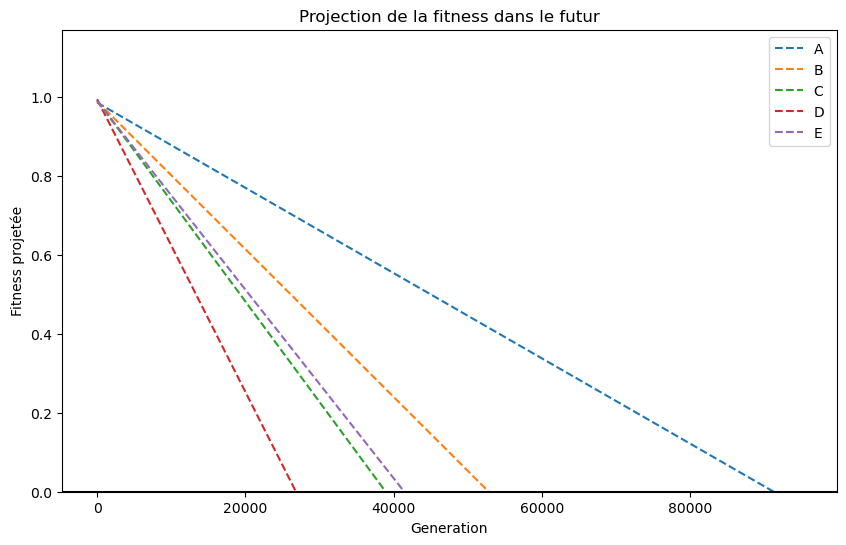

In [149]:
plt.figure(figsize=(10,6))

for scen in data_mean["scenario"].unique():
    
    dfp = data_mean[data_mean["scenario"]==scen]
    
    slope, intercept, *_ = linregress(dfp["gen"], dfp["fitness_mean"])
    
    future_gen = np.linspace(0,95000,500)
    future_fit = intercept + slope * future_gen
    
    plt.plot(future_gen, future_fit, "--", label=scen)

plt.axhline(0, color="black")
plt.title("Projection de la fitness dans le futur")
plt.xlabel("Generation")
plt.ylabel("Fitness projetée")
plt.legend()
plt.ylim(bottom=0) 
plt.show()

## Explication de la projection de la fitness

Dans cette figure, nous avons réalisé une **projection linéaire** de la **fitness moyenne** pour chaque scénario. L’objectif n’est pas de représenter une évolution **réelle**, mais simplement de **visualiser la tendance générale** observée dans nos simulations. En effet, dans la réalité, l’évolution d’une population n’est pas **linéaire** et dépend de plusieurs facteurs comme la **dérive génétique**, la **sélection naturelle**, la **migration** ou encore l’apparition **de nouvelles mutations**.

Pour construire cette projection, nous avons d’abord utilisé les valeurs de **fitness moyenne** en fonction du nombre de **générations** pour chaque scénario. Ensuite, nous avons appliqué une **régression linéaire** afin d’obtenir une droite représentant la tendance globale. Nous avons ensuite prolongé cette droite vers des **générations futures** pour mieux comparer l’évolution possible entre les différents scénarios.

Il est donc important de préciser que cette projection reste une **approximation simplifiée**. Elle sert surtout d’**outil visuel** pour comparer les scénarios et montrer que certains semblent plus **stables**, tandis que d’autres présentent une **diminution plus rapide** de la fitness. Elle ne doit pas être interprétée comme une **prédiction réelle** de l’évolution future des populations.

### risque_evolutif

In [160]:
risque = data_mean[data_mean["gen"] == 2000].copy()

risque["risque_evolutif"] = (
    - risque["fitness_mean"]
    + risque["genetic_load"]
)

risque[["scenario", "risque_evolutif"]].sort_values("risque_evolutif")

,scenario,risque_evolutif
39,A,4.264185
79,B,9.318255
199,E,11.633957
119,C,12.339783
159,D,18.289804


## Interprétation du risque évolutif

Ce tableau compare le **risque évolutif** des scénarios à la génération 2000.  
Plus la valeur est **élevée**, plus la population est **vulnérable génétiquement**.

Le **scénario A** est le **plus stable** car la population est **grande et non fragmentée**.  
Les scénarios **fragmentés** (surtout **D**) présentent un **risque plus important**, ce qui montre que la **fragmentation** et la **petite taille des populations** augmentent les difficultés évolutives.

## Limites du modèle

Notre modèle reste simplifié :

- il ne représente pas le génome réel de l’ours polaire,
- il ne prend pas en compte le climat,
- il ne prend pas en compte les maladies,
- la migration est modélisée de manière simple entre populations voisines,
- les mutations sont considérées de manière indépendante.

L’objectif n’est donc pas de reproduire exactement l’ours polaire réel, mais de modéliser des mécanismes génétiques généraux inspirés des données sur l’ours polaire.

# Conclusion

Au début de ce projet, l’étude de la **fragmentation des populations** et l’utilisation du logiciel **SLiM** représentaient pour nous un véritable **défi**. Nous avons dû apprendre à comprendre les **simulations évolutives**, analyser les **données** et interpréter les différents **graphiques**. Avec le temps, nous avons réussi à mieux maîtriser ces outils et à construire une analyse cohérente.

## Interprétation des résultats

### Graphe de la **taille de population**
On observe que les populations **grandes et non fragmentées** restent globalement **stables** dans le temps. En revanche, lorsque la population est **divisée en plusieurs sous-populations**, certaines tailles diminuent plus rapidement. Cela montre que la **petite taille effective** rend les groupes plus sensibles à la **dérive génétique**.

### Graphe de la **fitness moyenne**
La **fitness** diminue progressivement dans tous les scénarios, mais cette diminution est **plus rapide** lorsque la population est **fragmentée**. Les populations isolées accumulent plus facilement des **effets génétiques négatifs**, ce qui réduit leur capacité d’**adaptation**.

### Graphe des **mutations délétères**
Le nombre de **mutations délétères** augmente au cours du temps. Cette augmentation est **plus marquée** dans les scénarios avec **forte fragmentation**, car la **sélection naturelle** agit moins efficacement dans les petites populations.

### Graphe des **mutations bénéfiques**
Les mutations **bénéfiques** apparaissent dans tous les scénarios mais leur effet reste **limité**, surtout dans les populations **fragmentées** où leur diffusion est plus **lente**.

### Graphe de la **charge génétique**
La **charge génétique** augmente progressivement dans l’ensemble des scénarios. Cette augmentation est **plus importante** lorsque la fragmentation est **élevée**, traduisant une **accumulation de mutations négatives**.

### Graphe du **taux d’extinction**
Le **risque d’extinction** reste très **faible** dans une population **unique et de grande taille**, alors qu’il devient **plus élevé** lorsque la population est **divisée en plusieurs sous-groula plus **vulné globale

-lobale# Conclusion générale

Cette étude montre que la **taille de population** et le niveau de **fragmentation** ont un impact majeur sur l’**évolution génétique**. Une population **grande et connectée** conserve mieux sa **diversité génétique**, maintient une **fitness plus élevée** et présente un **faible risque d’extinction**. À l’inverse, la **fragmentation** entraîne une **augmentation de la dérive génétique**, une **accumulation de mutations délétères** et une **diminution progressive de la fitness**. La **migration** peut atténuer ces effets en favorisant le **flux de gènes**, mais elle ne suffit pas à compenser une fragmentation **trop importante**. Ainsi, les scénarios les plus **fragmentés** apparaissent comme les plus **défavorables** pour la survie à long terme des populations.